# 2026 Hungarian Grand Prix: External Candidate Follow-up

## Purpose and chronology

This notebook is an independent, post-audit follow-up to
`01_hungarian_gp_2026_story_discovery.ipynb`. Notebook 1's own story-discovery
audit closed with the editorial decision `NO MAIN-ARTICLE-STRENGTH STORY
IDENTIFIED`.

After that closure, three further candidates were identified through an
**external search performed after Notebook 1's original discovery pipeline
had already finished**. They were not surfaced by, and are not part of,
Notebook 1's own broad discovery process (Stages 1-8). They are analyzed
here, in a separate notebook, specifically to preserve that chronology and to
avoid retroactively inserting post-hoc candidates into Notebook 1's
methodology or conclusions.

This notebook does not modify, re-execute, or require Notebook 1 at runtime. It loads its own FastF1 session independently and builds its
FastF1-derived analytical tables and figures from that load. The VSC
timestamp reconciliation additionally reads the preserved OpenF1
race-control evidence file.

## Candidates evaluated here

- **E1** - McLaren second-stop inversion (Piastri vs. Norris).
- **E2** - Antonelli-Hamilton VSC sequence.
- **E3** - Verstappen VSC stay-out (bounded screening only).

A negative conclusion — none of these being strong enough for a standalone
article — is a valid outcome of this notebook, exactly as it was for
Notebook 1.

## Environment and dependency check

This cell prints the Python version, operating system, FastF1 version, key
scientific Python package versions, and the Python executable **name only**
(never an absolute path), following the same portable convention already
used in Notebook 1. It only inspects the current environment and does not
load race data.

In [1]:
import sys
import platform
from pathlib import Path

import fastf1
import pandas as pd
import numpy as np
import matplotlib
import IPython
import ipykernel

print("Python        :", sys.version.replace("\n", " "))
print("Platform      :", platform.platform())
print("FastF1        :", fastf1.__version__)
print("pandas        :", pd.__version__)
print("NumPy         :", np.__version__)
print("Matplotlib    :", matplotlib.__version__)
print("IPython       :", IPython.__version__)
print("ipykernel     :", ipykernel.__version__)
print("Executable    :", Path(sys.executable).name)

Python        : 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:59:26) [Clang 19.1.7 ]
Platform      : macOS-26.3-arm64-arm-64bit
FastF1        : 3.8.3
pandas        : 2.3.3
NumPy         : 2.4.4
Matplotlib    : 3.10.9
IPython       : 9.13.0
ipykernel     : 7.2.0
Executable    : python


## FastF1 cache configuration

Before loading the session, this notebook enables FastF1's local cache using
the same portable configuration pattern as Notebook 1: an explicit
`FASTF1_CACHE` environment variable is preferred, falling back to
`XDG_CACHE_HOME`, and finally to a per-user cache default. The cache is an
operational dependency stored outside the repository, not a project result.

In [2]:
import os
from pathlib import Path

default_cache_root = Path(
    os.environ.get("XDG_CACHE_HOME", Path.home() / ".cache")
)

FASTF1_CACHE_DIR = Path(
    os.environ.get(
        "FASTF1_CACHE",
        default_cache_root / "fastf1" / "Hungarian_GP_2026",
    )
).expanduser()

FASTF1_CACHE_DIR.mkdir(parents=True, exist_ok=True)
fastf1.Cache.enable_cache(str(FASTF1_CACHE_DIR))

cache_source = (
    "FASTF1 environment variable"
    if os.environ.get("FASTF1_CACHE")
    else "per-user cache default"
)
print("FastF1 cache configured:", cache_source)

FastF1 cache configured: per-user cache default


## Independent session load

This notebook loads its own session object and does not reuse or depend on
any in-memory object from Notebook 1. Telemetry and weather are excluded,
matching Notebook 1's own scope.

In [3]:
session = fastf1.get_session(2026, "Hungary", "R")
session.load(
    laps=True,
    telemetry=False,
    weather=False,
    messages=True,
)

laps = session.laps.copy()
laps["LapTimeSec"] = laps["LapTime"].dt.total_seconds()

print("Session loaded independently:", session)
print("laps.shape:", laps.shape)

core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '11'
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '12', '16', '44', '6', '63', '30', '27', '41', '5', '10', '18', '14', '43', '31', '23', '55', '87', '81', '11', '77']


Session loaded independently: 2026 Season Round 11: Hungarian Grand Prix - Race
laps.shape: (1431, 32)


## Shared metric: FastF1 lap-boundary time difference

Every pairwise driver-time comparison in E1 and E2 uses the FastF1
lap-boundary time difference defined below, named precisely to avoid
overclaiming: the **FastF1 lap-boundary time difference**. This is
deliberately not called an official "gap" or "live-timing interval."

For two drivers A and B, at completed lap N, using FastF1's cumulative
session `Time` field (elapsed session time at which that driver completed
lap N):

```
LapBoundaryDifference_A_minus_B(N) = A.Time(N) - B.Time(N)
```

**Sign convention**:
- **Negative**: driver A completed that lap boundary earlier and was ahead
  by the reconstructed measure.
- **Positive**: driver B completed that lap boundary earlier and was ahead.

**What this is**: a lap-boundary reconstruction computed locally from
FastF1's own cumulative `Time` field.

**What this is not**: the official, continuously sampled, instantaneous
interval between two cars at one clock tick (of the kind a live TV timing
tower or OpenF1's `intervals` endpoint would show). It compares "elapsed time
to complete lap N" between two drivers, not their live separation at a
single instant. This distinction is disclosed here once and applies
specifically to the later PIA-NOR (E1) and ANT-HAM (E2) lap-boundary
tables, charts, and interpretations. Other calculations in this notebook --
including phase sums, timestamps, position records, pit records, and
tyre-life records -- are separate observed or derived quantities and do not
use this specific metric.

## Promotion criteria declared before the candidate-analysis sections

These criteria are stated here, before any candidate's results are computed
below, and are applied unchanged afterward.

A candidate may qualify for `STANDALONE ARTICLE` only if **all** of the
following hold:

1. The central effect is reproducible from documented fields and
   calculations.
2. It survives reasonable boundary and window sensitivity checks.
3. Its interpretation does not require an unsupported counterfactual.
4. It has a meaningful sporting or strategic consequence.
5. Its central quantitative contribution has not already been substantially
   published.
6. It can be communicated without unsupported causal attribution.
7. It is independently reproducible from this repository and a fresh FastF1
   session load.

**Available dispositions**:
- `STANDALONE ARTICLE`
- `SECONDARY / SHORT-FORM`
- `CONTEXTUAL FINDING ONLY`
- `REJECT — DUPLICATIVE`
- `REJECT — UNANSWERABLE`
- `REJECT — OVERCLAIM-PRONE`

# E1 — McLaren second-stop inversion

**Research question**: How did Norris convert a 0.762-second lap-boundary
deficit after lap 32 into a 2.083-second lead after both McLarens completed
their second-stop cycle?

**Drivers**: PIA, NOR. **Window**: principally laps 28-42.

Claims to verify independently below, not accepted at face value:
- Piastri's `PitInTime` recorded on lap 33, `PitOutTime` on lap 34.
- Norris's `PitInTime` recorded on lap 39, `PitOutTime` on lap 40.
- PIA-NOR lap-boundary difference after lap 32: approximately -0.762 s.
- PIA-NOR lap-boundary difference after lap 40: approximately +2.083 s.
- Total inversion: approximately +2.845 s.

In [4]:
required_columns = [
    "Driver", "LapNumber", "LapTime", "Time", "Stint", "Compound",
    "TyreLife", "PitInTime", "PitOutTime", "TrackStatus", "Position",
]
missing_columns = sorted(set(required_columns) - set(laps.columns))
assert not missing_columns, f"Missing required columns: {missing_columns}"

e1_window = list(range(28, 43))

pia_e1 = (
    laps.loc[laps["Driver"].eq("PIA") & laps["LapNumber"].isin(e1_window)]
    .sort_values("LapNumber")
    .copy()
)
nor_e1 = (
    laps.loc[laps["Driver"].eq("NOR") & laps["LapNumber"].isin(e1_window)]
    .sort_values("LapNumber")
    .copy()
)

assert not pia_e1["LapNumber"].duplicated().any(), "Duplicate PIA lap numbers"
assert not nor_e1["LapNumber"].duplicated().any(), "Duplicate NOR lap numbers"
assert pia_e1["Time"].notna().all(), "PIA has missing Time values in window"
assert nor_e1["Time"].notna().all(), "NOR has missing Time values in window"

pia_e1_idx = pia_e1.set_index("LapNumber")
nor_e1_idx = nor_e1.set_index("LapNumber")

pia_stop_in = pia_e1_idx.loc[33, "PitInTime"]
pia_stop_out = pia_e1_idx.loc[34, "PitOutTime"]
nor_stop_in = nor_e1_idx.loc[39, "PitInTime"]
nor_stop_out = nor_e1_idx.loc[40, "PitOutTime"]

assert pd.notna(pia_stop_in), "Piastri PitInTime on lap 33 not found"
assert pd.notna(pia_stop_out), "Piastri PitOutTime on lap 34 not found"
assert pd.notna(nor_stop_in), "Norris PitInTime on lap 39 not found"
assert pd.notna(nor_stop_out), "Norris PitOutTime on lap 40 not found"

print("Verified: Piastri PitInTime lap 33 / PitOutTime lap 34.")
print("Verified: Norris PitInTime lap 39 / PitOutTime lap 40.")
print()
print("PIA laps 28-42:")
print(
    pia_e1[
        ["LapNumber", "LapTime", "Time", "PitInTime", "PitOutTime", "TrackStatus"]
    ].to_string(index=False)
)
print()
print("NOR laps 28-42:")
print(
    nor_e1[
        ["LapNumber", "LapTime", "Time", "PitInTime", "PitOutTime", "TrackStatus"]
    ].to_string(index=False)
)

Verified: Piastri PitInTime lap 33 / PitOutTime lap 34.
Verified: Norris PitInTime lap 39 / PitOutTime lap 40.

PIA laps 28-42:
 LapNumber                LapTime                   Time              PitInTime             PitOutTime TrackStatus
      28.0 0 days 00:01:25.122000 0 days 01:34:22.856000                    NaT                    NaT           1
      29.0 0 days 00:01:25.832000 0 days 01:35:48.688000                    NaT                    NaT           1
      30.0 0 days 00:01:25.735000 0 days 01:37:14.423000                    NaT                    NaT           1
      31.0 0 days 00:01:25.843000 0 days 01:38:40.266000                    NaT                    NaT           1
      32.0 0 days 00:01:25.831000 0 days 01:40:06.097000                    NaT                    NaT           1
      33.0 0 days 00:01:28.013000 0 days 01:41:34.110000 0 days 01:41:32.517000                    NaT           1
      34.0 0 days 00:01:44.099000 0 days 01:43:18.209000           

In [5]:
e1_paired = (
    pia_e1[["LapNumber", "LapTimeSec", "Time"]]
    .merge(
        nor_e1[["LapNumber", "LapTimeSec", "Time"]],
        on="LapNumber",
        how="inner",
        suffixes=("_PIA", "_NOR"),
        validate="one_to_one",
    )
    .sort_values("LapNumber")
    .reset_index(drop=True)
)

assert e1_paired["LapNumber"].is_unique
assert e1_paired["Time_PIA"].notna().all() and e1_paired["Time_NOR"].notna().all()

e1_paired["LapBoundaryDifference_PIA_minus_NOR"] = (
    (e1_paired["Time_PIA"] - e1_paired["Time_NOR"]).dt.total_seconds()
)

print(
    "FastF1 lap-boundary time difference, PIA-NOR "
    "(negative = PIA ahead, positive = NOR ahead):"
)
print(
    e1_paired[
        ["LapNumber", "LapBoundaryDifference_PIA_minus_NOR"]
    ].to_string(
        index=False,
        formatters={"LapBoundaryDifference_PIA_minus_NOR": "{:+.3f}".format},
    )
)

diff_at = e1_paired.set_index("LapNumber")["LapBoundaryDifference_PIA_minus_NOR"]

lap32_value = diff_at.loc[32]
lap40_value = diff_at.loc[40]
total_inversion = lap40_value - lap32_value

print()
print(f"Value after lap 32: {lap32_value:+.3f} s (expected approximately -0.762 s)")
print(f"Value after lap 40: {lap40_value:+.3f} s (expected approximately +2.083 s)")
print(f"Total inversion   : {total_inversion:+.3f} s (expected approximately +2.845 s)")

assert abs(lap32_value - (-0.762)) < 0.01, "Lap-32 value does not match expected -0.762 s"
assert abs(lap40_value - 2.083) < 0.01, "Lap-40 value does not match expected +2.083 s"
assert abs(total_inversion - 2.845) < 0.01, "Total inversion does not match expected +2.845 s"

print()
print("All E1 headline values reproduced within tolerance.")

FastF1 lap-boundary time difference, PIA-NOR (negative = PIA ahead, positive = NOR ahead):
 LapNumber LapBoundaryDifference_PIA_minus_NOR
      28.0                              -0.757
      29.0                              -1.471
      30.0                              -0.977
      31.0                              -0.711
      32.0                              -0.762
      33.0                              +1.837
      34.0                             +21.312
      35.0                             +20.540
      36.0                             +19.939
      37.0                             +20.984
      38.0                             +22.841
      39.0                             +19.806
      40.0                              +2.083
      41.0                              +3.750
      42.0                              +4.971

Value after lap 32: -0.762 s (expected approximately -0.762 s)
Value after lap 40: +2.083 s (expected approximately +2.083 s)
Total inversion   : +2.845 s (

In [6]:
def phase_sum(paired_frame, laps_subset):
    subset = paired_frame.loc[paired_frame["LapNumber"].isin(laps_subset)]
    assert set(subset["LapNumber"]) == set(laps_subset), (
        f"Missing laps in subset: {set(laps_subset) - set(subset['LapNumber'])}"
    )
    per_lap_delta = subset["LapTimeSec_PIA"] - subset["LapTimeSec_NOR"]
    return per_lap_delta.sum()

phase_35_36 = phase_sum(e1_paired, [35, 36])
phase_37_38 = phase_sum(e1_paired, [37, 38])
common_lap_net = phase_35_36 + phase_37_38
remaining_pit_cycle_window_residual = total_inversion - common_lap_net

print("Phase decomposition of the total inversion (PIA LapTime - NOR LapTime):")
print(f"  Laps 35-36 (Piastri gained)         : {phase_35_36:+.3f} s")
print(f"  Laps 37-38 (Piastri lost, traffic/incident window): {phase_37_38:+.3f} s")
print(f"  Common-lap net (35-38)               : {common_lap_net:+.3f} s")
print(f"  Total inversion (lap 32 -> lap 40)    : {total_inversion:+.3f} s")
print(
    "  Remaining pit-cycle-window residual  :"
    f" {remaining_pit_cycle_window_residual:+.3f} s"
)
print()
print(
    "The 'remaining pit-cycle-window residual' is NOT labeled pure pit-stop "
    "loss. It is a residual left after removing the selected common-lap "
    "component across laps 35-38 from the total inversion, and it can "
    "contain in-lap, out-lap, tyre warm-up, traffic, timing-boundary, "
    "pit-lane, and incident-related effects together. This notebook does "
    "not decompose it further."
)

assert abs(phase_35_36 - (-1.373)) < 0.01, "Laps 35-36 value does not match expected -1.373 s"
assert abs(phase_37_38 - 2.902) < 0.01, "Laps 37-38 value does not match expected +2.902 s"
assert abs(remaining_pit_cycle_window_residual - 1.316) < 0.02, (
    "Remaining pit-cycle-window residual does not match expected ~1.316 s"
)

Phase decomposition of the total inversion (PIA LapTime - NOR LapTime):
  Laps 35-36 (Piastri gained)         : -1.373 s
  Laps 37-38 (Piastri lost, traffic/incident window): +2.902 s
  Common-lap net (35-38)               : +1.529 s
  Total inversion (lap 32 -> lap 40)    : +2.845 s
  Remaining pit-cycle-window residual  : +1.316 s

The 'remaining pit-cycle-window residual' is NOT labeled pure pit-stop loss. It is a residual left after removing the selected common-lap component across laps 35-38 from the total inversion, and it can contain in-lap, out-lap, tyre warm-up, traffic, timing-boundary, pit-lane, and incident-related effects together. This notebook does not decompose it further.


In [7]:
print("Boundary sensitivity: valid pre-cycle and post-cycle combinations")
print(
    "Laps 33 and 39 are excluded as boundaries because they are themselves "
    "pit-affected (lap 33 carries Piastri's PitInTime; lap 39 carries "
    "Norris's PitInTime), so they cannot serve as clean pre- or post-cycle "
    "reference points."
)
print()

pre_cycle_laps = [31, 32]
post_cycle_laps = [40, 41, 42]

boundary_rows = []
for pre_lap in pre_cycle_laps:
    for post_lap in post_cycle_laps:
        pre_value = diff_at.loc[pre_lap]
        post_value = diff_at.loc[post_lap]
        boundary_rows.append(
            {
                "PreBoundaryLap": pre_lap,
                "PostBoundaryLap": post_lap,
                "PreDifferenceSec": pre_value,
                "PostDifferenceSec": post_value,
                "TotalInversionSec": post_value - pre_value,
            }
        )

boundary_sensitivity = pd.DataFrame(boundary_rows)
print(
    boundary_sensitivity.to_string(
        index=False,
        formatters={
            "PreDifferenceSec": "{:+.3f}".format,
            "PostDifferenceSec": "{:+.3f}".format,
            "TotalInversionSec": "{:+.3f}".format,
        },
    )
)

assert (boundary_sensitivity["TotalInversionSec"] > 0).all(), (
    "At least one valid pre/post boundary combination did not preserve a "
    "positive inversion"
)

expected_inversions = {
    (31, 40): 2.794, (31, 41): 4.461, (31, 42): 5.682,
    (32, 40): 2.845, (32, 41): 4.512, (32, 42): 5.733,
}
for _, row in boundary_sensitivity.iterrows():
    key = (row["PreBoundaryLap"], row["PostBoundaryLap"])
    assert abs(row["TotalInversionSec"] - expected_inversions[key]) < 0.01, (
        f"Boundary combination {key} does not match expected inversion"
    )

print()
print(
    "All valid boundary combinations preserve a positive inversion, "
    "matching expected values."
)

print()
print("Leave-one-out check over the four common laps 35-38 (saved results):")
common_deltas = (
    e1_paired.loc[e1_paired["LapNumber"].between(35, 38)]
    .set_index("LapNumber")
    .assign(Delta=lambda f: f["LapTimeSec_PIA"] - f["LapTimeSec_NOR"])["Delta"]
)
for dropped_lap in common_deltas.index:
    remaining_sum = common_deltas.drop(index=dropped_lap).sum()
    print(
        f"  excluding lap {dropped_lap}: remaining 3-lap sum = "
        f"{remaining_sum:+.3f} s"
    )

print()
print("Laps 35-36 and laps 37-38 presented separately (not netted):")
print(f"  laps 35-36: {phase_35_36:+.3f} s")
print(f"  laps 37-38: {phase_37_38:+.3f} s")

print()
print(
    "The overall second-stop inversion is stable across valid nearby "
    "pre-cycle and post-cycle boundaries. The selected laps 35-38 "
    "common-lap component is not leave-one-out stable: removing lap 38 "
    "reverses its sign. The decomposition is therefore incident-window-"
    "sensitive even though the overall inversion remains robust."
)

print()
print(
    "No portion of the 37-38 loss (+2.902 s) is attributed solely to the "
    "Sainz-Piastri contact by this notebook. The incident is examined "
    "separately below as a documented, time-aligned event, not as a "
    "quantified causal component of this number."
)

Boundary sensitivity: valid pre-cycle and post-cycle combinations
Laps 33 and 39 are excluded as boundaries because they are themselves pit-affected (lap 33 carries Piastri's PitInTime; lap 39 carries Norris's PitInTime), so they cannot serve as clean pre- or post-cycle reference points.

 PreBoundaryLap  PostBoundaryLap PreDifferenceSec PostDifferenceSec TotalInversionSec
             31               40           -0.711            +2.083            +2.794
             31               41           -0.711            +3.750            +4.461
             31               42           -0.711            +4.971            +5.682
             32               40           -0.762            +2.083            +2.845
             32               41           -0.762            +3.750            +4.512
             32               42           -0.762            +4.971            +5.733

All valid boundary combinations preserve a positive inversion, matching expected values.

Leave-one-out che

## Incident alignment: Sainz-Piastri contact and Piastri's own lap boundaries

The FastF1 race-control message about this incident carries a `Lap` field of
39. This section checks whether the incident's own embedded time places it
inside a different lap of Piastri's, using FastF1 timestamps rather than
relying on the message's `Lap` field alone.

In [8]:
import re
from zoneinfo import ZoneInfo

rcm = session.race_control_messages.copy()
rcm["LapNumeric"] = pd.to_numeric(rcm["Lap"], errors="coerce")

incident_rows = rcm.loc[
    rcm["Message"].str.contains("55 (SAI)", regex=False, na=False)
    & rcm["Message"].str.contains("81 (PIA)", regex=False, na=False)
    & rcm["Message"].str.contains(
        "NOTED - CAUSING A COLLISION",
        case=False,
        regex=False,
        na=False,
    )
]

assert len(incident_rows) == 1, (
    "Expected exactly one original NOTED incident row, "
    f"found {len(incident_rows)}."
)

incident_row = incident_rows.iloc[0]

assert int(incident_row["Lap"]) == 39, (
    f"Expected the original NOTED message to be logged on lap 39, "
    f"found lap {incident_row['Lap']}."
)

later_investigation_rows = rcm.loc[
    rcm["Message"].str.contains("55 (SAI)", regex=False, na=False)
    & rcm["Message"].str.contains("81 (PIA)", regex=False, na=False)
    & rcm["Message"].str.contains(
        "UNDER INVESTIGATION - CAUSING A COLLISION",
        case=False,
        regex=False,
        na=False,
    )
]

assert len(later_investigation_rows) == 1, (
    "Expected exactly one UNDER INVESTIGATION follow-up row, "
    f"found {len(later_investigation_rows)}"
)

later_investigation_row = later_investigation_rows.iloc[0]
assert int(later_investigation_row["Lap"]) == 40, (
    "Expected the UNDER INVESTIGATION follow-up on lap 40"
)

print(
    "Separate lap-40 UNDER INVESTIGATION follow-up row confirmed (not used "
    f"for incident-timing alignment): lap {int(later_investigation_row['Lap'])}"
)

print("Race-control message (as logged):")
print(f"  Time (absolute, as recorded) : {incident_row['Time']}")
print(f"  Lap field (as recorded)      : {incident_row['LapNumeric']:.0f}")
print(f"  Message                      : {incident_row['Message']}")

# The message embeds a local-circuit time in parentheses, e.g. "(15:57:04)".
# Parse it directly from the selected message rather than hardcoding it.
incident_time_match = re.search(
    r"\((\d{2}:\d{2}:\d{2})\)\s*$",
    str(incident_row["Message"]),
)
assert incident_time_match is not None, (
    "Could not parse the embedded incident time from the selected message"
)

incident_local_clock = incident_time_match.group(1)
incident_date = pd.Timestamp(incident_row["Time"]).date()

embedded_local_time = pd.Timestamp(
    f"{incident_date} {incident_local_clock}",
    tz=ZoneInfo("Europe/Budapest"),
)
incident_actual_time_utc = (
    embedded_local_time
    .tz_convert("UTC")
    .tz_localize(None)
)
print()
print(f"Embedded local (Europe/Budapest) time in message text: {embedded_local_time.time()}")
print(f"Converted to UTC (timezone-aware conversion)          : {incident_actual_time_utc}")

# Derive both available session-time offsets from the two matched VSC rows
# (FastF1's session-relative track_status.Time vs. its own absolute
# race_control_messages.Time for the same two events). Both come from the
# same FastF1 session feed, so these are two event-derived offsets, not two
# independent sources.
track_status = session.track_status.copy()
vsc_deployed_relative = track_status.loc[
    track_status["Status"].eq("6"), "Time"
].iloc[0]
vsc_ending_relative = track_status.loc[
    track_status["Status"].eq("7"), "Time"
].iloc[0]

vsc_deployed_absolute = rcm.loc[
    rcm["Message"].str.contains("VSC DEPLOYED", case=False, na=False), "Time"
].iloc[0]
vsc_ending_absolute = rcm.loc[
    rcm["Message"].str.contains("VSC ENDING", case=False, na=False), "Time"
].iloc[0]

offset_from_deployed = vsc_deployed_absolute - vsc_deployed_relative
offset_from_ending = vsc_ending_absolute - vsc_ending_relative
offset_uncertainty = abs(
    (offset_from_deployed - offset_from_ending).total_seconds()
)

print()
print(
    "Two event-derived session-time offsets (both derived from the same "
    "FastF1 session feed, not independent sources):"
)
print(f"  from VSC-deployed row: {offset_from_deployed}")
print(f"  from VSC-ending row  : {offset_from_ending}")
print(f"  alignment uncertainty: {offset_uncertainty * 1000:.0f} ms")

assert offset_uncertainty < 0.5, (
    "Offset uncertainty unexpectedly large; alignment not defensible"
)

pia_lap37_end_relative = pia_e1_idx.loc[37, "Time"]
pia_lap38_end_relative = pia_e1_idx.loc[38, "Time"]
pia_lap39_end_relative = pia_e1_idx.loc[39, "Time"]

pia_lap37_end_low = pia_lap37_end_relative + min(offset_from_deployed, offset_from_ending)
pia_lap37_end_high = pia_lap37_end_relative + max(offset_from_deployed, offset_from_ending)
pia_lap38_end_low = pia_lap38_end_relative + min(offset_from_deployed, offset_from_ending)
pia_lap38_end_high = pia_lap38_end_relative + max(offset_from_deployed, offset_from_ending)
pia_lap39_end_low = pia_lap39_end_relative + min(offset_from_deployed, offset_from_ending)
pia_lap39_end_high = pia_lap39_end_relative + max(offset_from_deployed, offset_from_ending)

print()
print("Piastri's lap 37/38/39 boundaries, converted under both offsets:")
print(f"  lap 37 end: {pia_lap37_end_low}  to  {pia_lap37_end_high}")
print(f"  lap 38 end: {pia_lap38_end_low}  to  {pia_lap38_end_high}")
print(f"  lap 39 end: {pia_lap39_end_low}  to  {pia_lap39_end_high}")

falls_in_lap38_low_offset = pia_lap37_end_low < incident_actual_time_utc <= pia_lap38_end_low
falls_in_lap38_high_offset = pia_lap37_end_high < incident_actual_time_utc <= pia_lap38_end_high

print()
print(f"Incident (embedded) time within Piastri's lap 38 window (low offset) : {falls_in_lap38_low_offset}")
print(f"Incident (embedded) time within Piastri's lap 38 window (high offset): {falls_in_lap38_high_offset}")

assert falls_in_lap38_low_offset and falls_in_lap38_high_offset, (
    "Incident time does not fall inside Piastri's lap 38 under both offsets"
)

message_after_lap38_low = incident_row["Time"] > pia_lap38_end_low
message_after_lap38_high = incident_row["Time"] > pia_lap38_end_high
message_within_lap39_low = incident_row["Time"] <= pia_lap39_end_low
message_within_lap39_high = incident_row["Time"] <= pia_lap39_end_high

print()
print(f"Message logging time after Piastri's lap 38 (low offset) : {message_after_lap38_low}")
print(f"Message logging time after Piastri's lap 38 (high offset): {message_after_lap38_high}")
print(f"Message logging time within Piastri's lap 39 (low offset) : {message_within_lap39_low}")
print(f"Message logging time within Piastri's lap 39 (high offset): {message_within_lap39_high}")

assert message_after_lap38_low and message_after_lap38_high
assert message_within_lap39_low and message_within_lap39_high

print()
print(
    "Conclusion, distinguishing three separate things: the embedded event "
    "time falls inside Piastri's lap 38 under both offsets (uncertainty "
    f"{offset_uncertainty * 1000:.0f} ms); the race-control message's own "
    "logging timestamp falls after lap 38 and inside Piastri's lap 39 "
    "under both offsets; and the message's Lap=39 field is consistent with "
    "that later logged note, not with the incident itself. No quantified "
    "portion of the +2.902 s laps 37-38 loss is attributed solely to the "
    "collision by this notebook."
)

Separate lap-40 UNDER INVESTIGATION follow-up row confirmed (not used for incident-timing alignment): lap 40
Race-control message (as logged):
  Time (absolute, as recorded) : 2026-07-26 13:58:52
  Lap field (as recorded)      : 39
  Message                      : TURN 2 INCIDENT INVOLVING CARS 55 (SAI) AND 81 (PIA) NOTED - CAUSING A COLLISION (15:57:04)

Embedded local (Europe/Budapest) time in message text: 15:57:04
Converted to UTC (timezone-aware conversion)          : 2026-07-26 13:57:04

Two event-derived session-time offsets (both derived from the same FastF1 session feed, not independent sources):
  from VSC-deployed row: 2026-07-26 12:09:09.836000
  from VSC-ending row  : 2026-07-26 12:09:09.928000
  alignment uncertainty: 92 ms

Piastri's lap 37/38/39 boundaries, converted under both offsets:
  lap 37 end: 2026-07-26 13:56:41.582000  to  2026-07-26 13:56:41.674000
  lap 38 end: 2026-07-26 13:58:07.946000  to  2026-07-26 13:58:08.038000
  lap 39 end: 2026-07-26 13:59:32.348000

### Incident-alignment interpretation

- **Directly observed**: the race-control message text, its `Time` and `Lap`
  fields, and Piastri's own `Time` values at each lap boundary.
- **Calculated locally**: the two candidate session-time offsets, their
  ~92 ms disagreement, and the conversion of Piastri's lap boundaries into
  approximate absolute time under each offset.
- **Interpretation**: the incident most likely occurred during Piastri's lap
  38, with the race-control note logged during Piastri's lap 39. This is offered as a
  timestamp-based reconciliation, not as an independently confirmed causal
  account of the incident itself.
- This does not change the quantitative laps 37-38 loss reported above; it
  only affects which of Piastri's laps the incident is most plausibly
  associated with.

## E1 originality assessment

**Existing publication**: F1Pedia, *2026 Hungarian GP Race Paper*
(<https://f1pedia.com/en/papers/2026-hungarian-gp-race-paper>), accessed
2026-07-31.

F1Pedia has already published substantially the same analytical story,
including:
- approximately 2.9 seconds lost across laps 37-38;
- a greater-than-one-second difference between the two McLarens' stop
  cycles;
- lap-by-lap timing information consistent with this notebook's own FastF1
  pull (its quoted Norris lap-41 time of 1:22.718 matches this notebook's
  own data exactly).

**External editorial assessment**: because the central quantitative story
here is already substantially available in existing analytical coverage,
this notebook does not treat E1 as an original standalone discovery. Its
maximum permitted disposition is:

`SECONDARY / SHORT-FORM`

This notebook reproduces and refines the calculation independently (adding
the phase split, sensitivity checks, and the incident-alignment analysis
above), but that refinement does not raise the disposition past
`SECONDARY / SHORT-FORM` given the pre-existing publication.

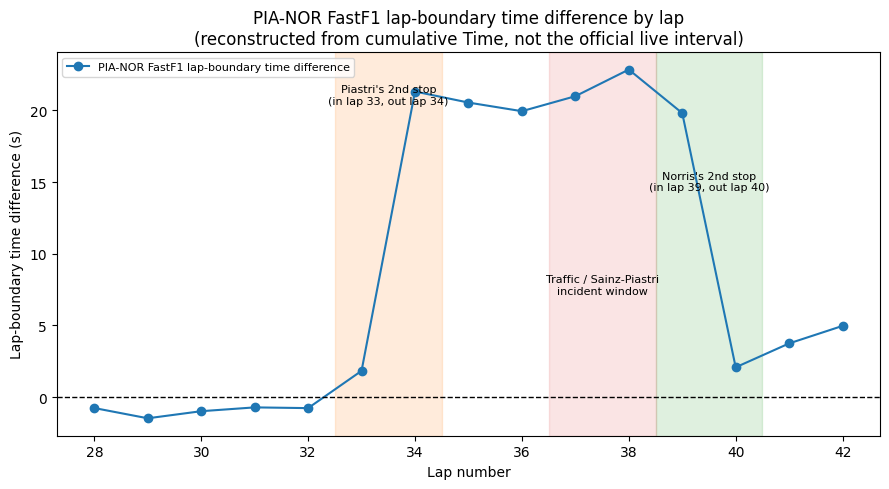

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    e1_paired["LapNumber"],
    e1_paired["LapBoundaryDifference_PIA_minus_NOR"],
    marker="o",
    color="tab:blue",
    label="PIA-NOR FastF1 lap-boundary time difference",
)
ax.axhline(0, color="black", linewidth=1, linestyle="--")

ax.axvspan(32.5, 34.5, color="tab:orange", alpha=0.15)
ax.annotate(
    "Piastri's 2nd stop\n(in lap 33, out lap 34)",
    xy=(33.5, ax.get_ylim()[1] * 0.85),
    ha="center",
    fontsize=8,
)

ax.axvspan(38.5, 40.5, color="tab:green", alpha=0.15)
ax.annotate(
    "Norris's 2nd stop\n(in lap 39, out lap 40)",
    xy=(39.5, ax.get_ylim()[1] * 0.6),
    ha="center",
    fontsize=8,
)

ax.axvspan(36.5, 38.5, color="tab:red", alpha=0.12)
ax.annotate(
    "Traffic / Sainz-Piastri\nincident window",
    xy=(37.5, ax.get_ylim()[1] * 0.3),
    ha="center",
    fontsize=8,
)

ax.set_xlabel("Lap number")
ax.set_ylabel("Lap-boundary time difference (s)")
ax.set_title(
    "PIA-NOR FastF1 lap-boundary time difference by lap\n"
    "(reconstructed from cumulative Time, not the official live interval)"
)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

### E1 disposition against the promotion criteria

1. Reproducible from documented fields — yes (headline and phase values all
   reproduced within tolerance above).
2. Survives boundary/window sensitivity checks — Partly. The overall
   inversion survives all valid nearby pre/post boundary combinations,
   but the laps 35-38 decomposition is sensitive to lap 38 and does not
   preserve its sign in every leave-one-out specification.
3. No unsupported counterfactual — yes (no stay-out or alternate-strategy
   counterfactual is computed).
4. Meaningful sporting/strategic consequence — yes (this decided the
   intra-team McLaren order at this point in the race).
5. Not already substantially published — **no** (F1Pedia, see above).
6. Communicable without unsupported causal attribution — yes, provided the
   37-38 loss and the residual are not attributed solely to the incident.
7. Independently reproducible — yes.

**Final disposition: `SECONDARY / SHORT-FORM`.** The sensitivity
limitation under criterion 2 and prior publication under criterion 5 both
keep E1 below `STANDALONE ARTICLE`; criterion 5 independently caps its
maximum disposition.

# E2 — Antonelli-Hamilton VSC sequence

**Research question**: How did the observed ANT-HAM lap-boundary time
difference change across Antonelli's green-flag stop, Hamilton's
VSC-assisted stop, and the subsequent VSC white-line position correction?

**Drivers**: ANT, HAM. **Window**: principally laps 48-60.

Claims to verify independently below:
- ANT-HAM after lap 52: approximately -6.002 s.
- ANT-HAM after lap 54: approximately +14.190 s.
- ANT-HAM after lap 57: approximately +1.388 s.
- ANT-HAM after lap 58: approximately -0.658 s.

In [10]:
e2_window = list(range(48, 61))

ant_e2 = (
    laps.loc[laps["Driver"].eq("ANT") & laps["LapNumber"].isin(e2_window)]
    .sort_values("LapNumber")
    .copy()
)
ham_e2 = (
    laps.loc[laps["Driver"].eq("HAM") & laps["LapNumber"].isin(e2_window)]
    .sort_values("LapNumber")
    .copy()
)

assert not ant_e2["LapNumber"].duplicated().any(), "Duplicate ANT lap numbers"
assert not ham_e2["LapNumber"].duplicated().any(), "Duplicate HAM lap numbers"
assert ant_e2["Time"].notna().all(), "ANT has missing Time values in window"
assert ham_e2["Time"].notna().all(), "HAM has missing Time values in window"

ant_e2_idx = ant_e2.set_index("LapNumber")
ham_e2_idx = ham_e2.set_index("LapNumber")

ant_pit_in = ant_e2_idx.loc[53, "PitInTime"]
ant_pit_out = ant_e2_idx.loc[54, "PitOutTime"]
ham_pit_in = ham_e2_idx.loc[56, "PitInTime"]
ham_pit_out = ham_e2_idx.loc[57, "PitOutTime"]

assert pd.notna(ant_pit_in), "Antonelli PitInTime on lap 53 not found"
assert pd.notna(ant_pit_out), "Antonelli PitOutTime on lap 54 not found"
assert pd.notna(ham_pit_in), "Hamilton PitInTime on lap 56 not found"
assert pd.notna(ham_pit_out), "Hamilton PitOutTime on lap 57 not found"

print("Verified: Antonelli PitInTime lap 53 / PitOutTime lap 54 (green-flag stop).")
print("Verified: Hamilton PitInTime lap 56 / PitOutTime lap 57 (VSC-affected stop).")
print()
print("ANT laps 48-60 (pit, compound, tyre-life, track status):")
print(
    ant_e2[
        [
            "LapNumber", "LapTime", "Time", "Stint", "Compound", "TyreLife",
            "PitInTime", "PitOutTime", "TrackStatus",
        ]
    ].to_string(index=False)
)
print()
print("HAM laps 48-60 (pit, compound, tyre-life, track status):")
print(
    ham_e2[
        [
            "LapNumber", "LapTime", "Time", "Stint", "Compound", "TyreLife",
            "PitInTime", "PitOutTime", "TrackStatus",
        ]
    ].to_string(index=False)
)

Verified: Antonelli PitInTime lap 53 / PitOutTime lap 54 (green-flag stop).
Verified: Hamilton PitInTime lap 56 / PitOutTime lap 57 (VSC-affected stop).

ANT laps 48-60 (pit, compound, tyre-life, track status):
 LapNumber                LapTime                   Time  Stint Compound  TyreLife              PitInTime             PitOutTime TrackStatus
      48.0 0 days 00:01:24.673000 0 days 02:02:57.564000    2.0     HARD      26.0                    NaT                    NaT           1
      49.0 0 days 00:01:24.882000 0 days 02:04:22.446000    2.0     HARD      27.0                    NaT                    NaT           1
      50.0 0 days 00:01:24.837000 0 days 02:05:47.283000    2.0     HARD      28.0                    NaT                    NaT          12
      51.0 0 days 00:01:24.827000 0 days 02:07:12.110000    2.0     HARD      29.0                    NaT                    NaT           1
      52.0 0 days 00:01:24.817000 0 days 02:08:36.927000    2.0     HARD      30.0  

In [11]:
e2_paired = (
    ant_e2[["LapNumber", "LapTimeSec", "Time"]]
    .merge(
        ham_e2[["LapNumber", "LapTimeSec", "Time"]],
        on="LapNumber",
        how="inner",
        suffixes=("_ANT", "_HAM"),
        validate="one_to_one",
    )
    .sort_values("LapNumber")
    .reset_index(drop=True)
)

assert e2_paired["LapNumber"].is_unique
assert e2_paired["Time_ANT"].notna().all() and e2_paired["Time_HAM"].notna().all()

e2_paired["LapBoundaryDifference_ANT_minus_HAM"] = (
    (e2_paired["Time_ANT"] - e2_paired["Time_HAM"]).dt.total_seconds()
)

print(
    "FastF1 lap-boundary time difference, ANT-HAM "
    "(negative = ANT ahead, positive = HAM ahead):"
)
print(
    e2_paired[
        ["LapNumber", "LapBoundaryDifference_ANT_minus_HAM"]
    ].to_string(
        index=False,
        formatters={"LapBoundaryDifference_ANT_minus_HAM": "{:+.3f}".format},
    )
)

e2_diff_at = e2_paired.set_index("LapNumber")["LapBoundaryDifference_ANT_minus_HAM"]

lap52_value = e2_diff_at.loc[52]
lap54_value = e2_diff_at.loc[54]
lap57_value = e2_diff_at.loc[57]
lap58_value = e2_diff_at.loc[58]

print()
print(f"Value after lap 52: {lap52_value:+.3f} s (expected approximately -6.002 s)")
print(f"Value after lap 54: {lap54_value:+.3f} s (expected approximately +14.190 s)")
print(f"Value after lap 57: {lap57_value:+.3f} s (expected approximately +1.388 s)")
print(f"Value after lap 58: {lap58_value:+.3f} s (expected approximately -0.658 s)")

assert abs(lap52_value - (-6.002)) < 0.01
assert abs(lap54_value - 14.190) < 0.01
assert abs(lap57_value - 1.388) < 0.01
assert abs(lap58_value - (-0.658)) < 0.01

print()
print("All E2 headline values reproduced within tolerance.")

FastF1 lap-boundary time difference, ANT-HAM (negative = ANT ahead, positive = HAM ahead):
 LapNumber LapBoundaryDifference_ANT_minus_HAM
      48.0                              -7.647
      49.0                              -7.551
      50.0                              -7.025
      51.0                              -6.412
      52.0                              -6.002
      53.0                              -3.240
      54.0                             +14.190
      55.0                             +12.295
      56.0                             +15.689
      57.0                              +1.388
      58.0                              -0.658
      59.0                              -0.531
      60.0                              -1.684

Value after lap 52: -6.002 s (expected approximately -6.002 s)
Value after lap 54: +14.190 s (expected approximately +14.190 s)
Value after lap 57: +1.388 s (expected approximately +1.388 s)
Value after lap 58: -0.658 s (expected approximately -0.658

## VSC timestamp check (FastF1 vs. preserved OpenF1 evidence)

`session.race_control_messages["Time"]` already carries an absolute FastF1
timestamp for these messages — no derived or approximate conversion is used
here. This is compared directly against the preserved OpenF1 evidence file
`evidence/openf1_hungary_2026_race_control.json`, which is read here
**read-only** and is not modified.

In [12]:
import json

vsc_deployed_msg = rcm.loc[
    rcm["Message"].str.contains("VSC DEPLOYED", case=False, na=False)
].iloc[0]
vsc_ending_msg = rcm.loc[
    rcm["Message"].str.contains("VSC ENDING", case=False, na=False)
].iloc[0]

fastf1_vsc_deployed_utc = vsc_deployed_msg["Time"].tz_localize("UTC")
fastf1_vsc_ending_utc = vsc_ending_msg["Time"].tz_localize("UTC")

print("FastF1 absolute VSC timestamps (already present, no conversion applied):")
print(f"  VSC deployed: {fastf1_vsc_deployed_utc}")
print(f"  VSC ending  : {fastf1_vsc_ending_utc}")

evidence_candidates = [
    Path("evidence/openf1_hungary_2026_race_control.json"),
    Path("../evidence/openf1_hungary_2026_race_control.json"),
]

evidence_path = next(
    (path for path in evidence_candidates if path.is_file()),
    None,
)

assert evidence_path is not None, (
    "OpenF1 race-control evidence file not found from the current "
    "working directory"
)
print("Resolved evidence path:", evidence_path)
with open(evidence_path) as f:
    openf1_race_control = json.load(f)

openf1_vsc_rows = [
    r for r in openf1_race_control if "VSC" in (r.get("message") or "")
]
assert len(openf1_vsc_rows) == 2, "Expected exactly 2 OpenF1 VSC messages"

openf1_deployed_utc = pd.Timestamp(
    [r["date"] for r in openf1_vsc_rows if "DEPLOYED" in r["message"]][0]
).tz_convert("UTC")
openf1_ending_utc = pd.Timestamp(
    [r["date"] for r in openf1_vsc_rows if "ENDING" in r["message"]][0]
).tz_convert("UTC")

print()
print("Preserved OpenF1 evidence VSC timestamps (read-only, unmodified file):")
print(f"  VSC deployed: {openf1_deployed_utc}")
print(f"  VSC ending  : {openf1_ending_utc}")

expected_deployed = pd.Timestamp("2026-07-26 14:22:55", tz="UTC")
expected_ending = pd.Timestamp("2026-07-26 14:24:13", tz="UTC")

assert fastf1_vsc_deployed_utc == expected_deployed
assert fastf1_vsc_ending_utc == expected_ending
assert openf1_deployed_utc == expected_deployed
assert openf1_ending_utc == expected_ending
assert fastf1_vsc_deployed_utc == openf1_deployed_utc
assert fastf1_vsc_ending_utc == openf1_ending_utc

print()
print(
    "Confirmed: FastF1's own absolute race-control timestamps agree exactly "
    "with the preserved OpenF1 evidence file for both VSC deployed "
    "(2026-07-26 14:22:55 UTC) and VSC ending (2026-07-26 14:24:13 UTC)."
)

FastF1 absolute VSC timestamps (already present, no conversion applied):
  VSC deployed: 2026-07-26 14:22:55+00:00
  VSC ending  : 2026-07-26 14:24:13+00:00
Resolved evidence path: ../evidence/openf1_hungary_2026_race_control.json

Preserved OpenF1 evidence VSC timestamps (read-only, unmodified file):
  VSC deployed: 2026-07-26 14:22:55+00:00
  VSC ending  : 2026-07-26 14:24:13+00:00

Confirmed: FastF1's own absolute race-control timestamps agree exactly with the preserved OpenF1 evidence file for both VSC deployed (2026-07-26 14:22:55 UTC) and VSC ending (2026-07-26 14:24:13 UTC).


In [13]:
print("E2 event-sequence continuity check")
print(
    "This is a reproducible event chronology, not a conventional "
    "sensitivity test using interchangeable boundaries. Hamilton's "
    "PitInTime is recorded on lap 56, and that lap carries VSC-related "
    "TrackStatus, so lap 56 is a pit-transition boundary, not a "
    "'before Hamilton's stop' observation. Laps 56 and 57 are each single "
    "event-transition observations rather than repeated phases."
)
print()
print("Full lap-boundary series, laps 48-60, for reference:")
print(
    e2_paired[
        ["LapNumber", "LapBoundaryDifference_ANT_minus_HAM"]
    ].to_string(
        index=False,
        formatters={"LapBoundaryDifference_ANT_minus_HAM": "{:+.3f}".format},
    )
)

phase_pre_antonelli_stop = e2_diff_at.loc[[51, 52]]
phase_post_antonelli_pre_hamilton_pit = e2_diff_at.loc[[54, 55]]
hamilton_vsc_pit_in_boundary = e2_diff_at.loc[[56]]
hamilton_pit_out_boundary = e2_diff_at.loc[[57]]
phase_after_white_line_return = e2_diff_at.loc[[58, 59, 60]]

print()
print(
    "State 1: before Antonelli's stop, laps 51-52 (expect ANT ahead, "
    "negative):"
)
print(phase_pre_antonelli_stop.to_string())
assert (phase_pre_antonelli_stop < 0).all(), (
    "Pre-Antonelli-stop state does not remain negative"
)

print()
print(
    "State 2: after Antonelli's stop and before Hamilton's pit-in lap, "
    "laps 54-55 (expect HAM ahead, positive):"
)
print(phase_post_antonelli_pre_hamilton_pit.to_string())
assert (phase_post_antonelli_pre_hamilton_pit > 0).all(), (
    "Post-Antonelli-stop / pre-Hamilton-pit-in state does not remain "
    "positive"
)

print()
print(
    "State 3: Hamilton's VSC pit-in boundary, lap 56 (expect HAM ahead, "
    "positive, approximately +15.689 s):"
)
print(hamilton_vsc_pit_in_boundary.to_string())
assert (hamilton_vsc_pit_in_boundary > 0).all()
assert abs(hamilton_vsc_pit_in_boundary.loc[56] - 15.689) < 0.01

print()
print(
    "State 4: Hamilton's pit-out boundary, before the documented position "
    "return, lap 57 (expect HAM ahead, positive, approximately +1.388 s):"
)
print(hamilton_pit_out_boundary.to_string())
assert (hamilton_pit_out_boundary > 0).all()
assert abs(hamilton_pit_out_boundary.loc[57] - 1.388) < 0.01

print()
print(
    "State 5: after the documented white-line position return, laps 58-60 "
    "(expect ANT ahead, negative):"
)
print(phase_after_white_line_return.to_string())
assert (phase_after_white_line_return < 0).all(), (
    "Post-white-line-return state does not remain negative"
)

print()
print(
    "This is a reproducible event chronology across five event-defined "
    "states, not a conventional sensitivity test using interchangeable "
    "boundaries. States 1, 2, and 5 are repeated multi-lap states that "
    "preserve their sign across their available consecutive laps; states 3 "
    "(lap 56, Hamilton's VSC pit-in) and 4 (lap 57, Hamilton's pit-out) are "
    "each single pit-transition observations, not repeated phases. The sign "
    "change between laps 57 and 58 is the documented position return."
)

E2 event-sequence continuity check
This is a reproducible event chronology, not a conventional sensitivity test using interchangeable boundaries. Hamilton's PitInTime is recorded on lap 56, and that lap carries VSC-related TrackStatus, so lap 56 is a pit-transition boundary, not a 'before Hamilton's stop' observation. Laps 56 and 57 are each single event-transition observations rather than repeated phases.

Full lap-boundary series, laps 48-60, for reference:
 LapNumber LapBoundaryDifference_ANT_minus_HAM
      48.0                              -7.647
      49.0                              -7.551
      50.0                              -7.025
      51.0                              -6.412
      52.0                              -6.002
      53.0                              -3.240
      54.0                             +14.190
      55.0                             +12.295
      56.0                             +15.689
      57.0                              +1.388
      58.0         

## E2 interpretation limit

**Official explanation for the lap-58 sign change**: the official Formula 1
race report
(<https://www.formula1.com/en/latest/article/norris-beats-verstappen-and-antonelli-to-victory-in-dramatic-hungarian-gp.5JQmohRAKABD2asRsMWogj>,
accessed 2026-07-31) states that Hamilton initially emerged from his stop
ahead of Antonelli, but ceded the position after replays showed Antonelli
had reached the relevant VSC white line at the end of the start/finish
straight first.

Accordingly, **this notebook describes the lap-58 sign change strictly as
the documented VSC white-line position return — not as an overtake, not as
a pace gain, and not as a tyre-driven position change.**

**Mercedes' own account**: the Mercedes race report
(<https://www.mercedesamgf1.com/reports/race-report-impressive-fightbacks-and-damage-limitation-in-budapest>,
accessed 2026-07-31) states qualitatively that "the Virtual Safety Car was
not ideal as it reduced that advantage and brought Lewis onto our gearbox,"
referring to Antonelli's tyre-offset advantage. It does not state or imply a
specific number of seconds the VSC cost Antonelli.

**This notebook may quantify the observed lap-boundary chronology above. It
must not, and does not, claim**:
- that the VSC cost Antonelli an exact number of seconds;
- a definitive no-VSC counterfactual result;
- that Antonelli would certainly have gained or lost a particular position
  without the VSC;
- that the lap-58 sign change resulted from tyre performance.

**Chart note**: the shaded VSC band in the chart below represents the
FastF1 lap records carrying VSC-related `TrackStatus` (laps 56-57). It does
not claim to plot the exact within-lap deployment or ending position -- the
exact UTC deployment and ending timestamps are reported in the preceding
timestamp-check table, not as chart x-axis positions.

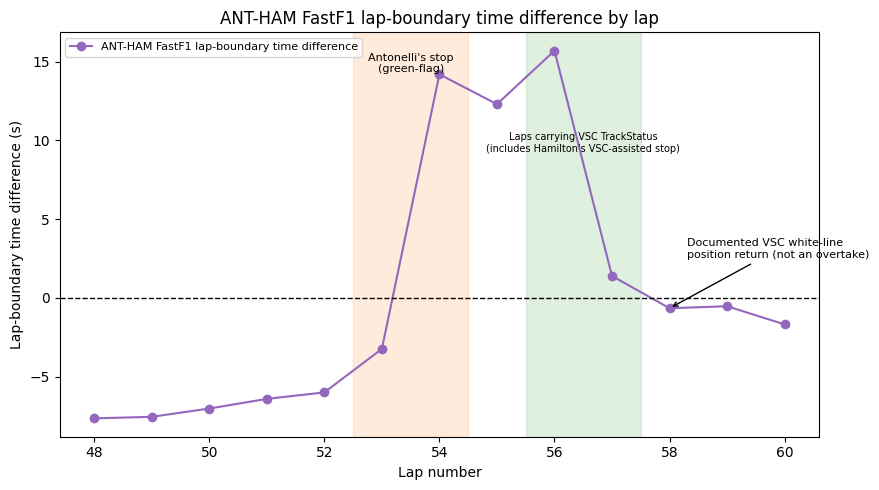

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    e2_paired["LapNumber"],
    e2_paired["LapBoundaryDifference_ANT_minus_HAM"],
    marker="o",
    color="tab:purple",
    label="ANT-HAM FastF1 lap-boundary time difference",
)
ax.axhline(0, color="black", linewidth=1, linestyle="--")

ax.axvspan(52.5, 54.5, color="tab:orange", alpha=0.15)
ax.annotate(
    "Antonelli's stop\n(green-flag)",
    xy=(53.5, ax.get_ylim()[1] * 0.85),
    ha="center",
    fontsize=8,
)

ax.axvspan(55.5, 57.5, color="tab:green", alpha=0.15)
ax.annotate(
    "Laps carrying VSC TrackStatus\n(includes Hamilton's VSC-assisted stop)",
    xy=(56.5, ax.get_ylim()[1] * 0.55),
    ha="center",
    fontsize=7,
)

ax.annotate(
    "Documented VSC white-line\nposition return (not an overtake)",
    xy=(58, lap58_value),
    xytext=(58.3, ax.get_ylim()[1] * 0.15),
    fontsize=8,
    arrowprops=dict(arrowstyle="->", lw=1),
)

ax.set_xlabel("Lap number")
ax.set_ylabel("Lap-boundary time difference (s)")
ax.set_title(
    "ANT-HAM FastF1 lap-boundary time difference by lap"
)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

### E2 disposition against the promotion criteria

1. Reproducible from documented fields — yes (all four headline values
   reproduced within tolerance).
2. Boundary/window sensitivity — Partly. The five event-defined states
   reproduce the expected chronology, and the repeated multi-lap states
   preserve their signs. However, laps 56 and 57 are single pit-transition
   observations rather than interchangeable sensitivity boundaries.
3. No unsupported counterfactual — yes, provided the lap-58 change is
   described only as the documented VSC white-line return.
4. Meaningful sporting/strategic consequence — Moderate but not
   independently podium-determining. The VSC compressed the podium fight,
   but this notebook cannot establish that it changed the final podium
   result.
5. Not already substantially published — The exact four-point lap-boundary
   chronology was not identified in the Formula 1, Mercedes and F1Pedia
   coverage reviewed on 31 July 2026. Those sources already document the
   qualitative strategy and white-line mechanism.
6. Communicable without unsupported causal attribution — yes, given the
   explicit limits in the interpretation section above.
7. Independently reproducible — yes.

**Final disposition: `SECONDARY / SHORT-FORM`.** This independently
reconstructed quantitative chronology was not identified in the Formula 1,
Mercedes, or F1Pedia coverage reviewed as of 31 July 2026. Its sporting
consequence, however, is moderate rather than podium-determining (criterion
4), and part of its explanatory content — the lap-58 change — is already
officially documented rather than newly discovered by this notebook.
Together, those limits keep it below `STANDALONE ARTICLE`, while the
quantitative chronology remains sufficiently original for
`SECONDARY / SHORT-FORM`. No VSC counterfactual is claimed.

# E3 — Verstappen VSC stay-out screening

This section is a **bounded screening analysis only**, per this notebook's
scope. It explicitly overlaps with Notebook 1's Module E ("Pit and position
sequence around the Virtual Safety Car") and with Notebook 1's rejected
Candidate 3 ("Norris's VSC lead margin, separated by second-place driver"),
which already examined the same VSC window and substantially overlapping drivers and did not advance
past a `Do not advance` disposition.

**What FastF1 can establish** (checked below): Verstappen did not pit during
the VSC; his stint, compound, and tyre-life sequence remained continuous;
his recorded position changed while surrounding drivers stopped.

**What FastF1 cannot establish**: the exact benefit relative to a
hypothetical stop; how much traffic protection specifically caused the
result; what Verstappen's final position would have been under another
strategy; or that staying out was objectively the correct strategy. None of
these are attempted here.

In [15]:
e3_window = list(range(52, 61))
e3_drivers = ["VER", "ANT", "HAM", "NOR", "LEC", "PIA"]

e3_table = (
    laps.loc[
        laps["Driver"].isin(e3_drivers) & laps["LapNumber"].isin(e3_window),
        [
            "Driver", "LapNumber", "Position", "Stint", "Compound",
            "TyreLife", "PitInTime", "PitOutTime", "TrackStatus",
        ],
    ]
    .sort_values(["Driver", "LapNumber"])
    .reset_index(drop=True)
)

assert not e3_table.duplicated(subset=["Driver", "LapNumber"]).any()

ver_e3 = e3_table.loc[e3_table["Driver"].eq("VER")].set_index("LapNumber")
ver_pitted = ver_e3["PitInTime"].notna().any() or ver_e3["PitOutTime"].notna().any()

print("Verstappen pit activity in this window:", "none" if not ver_pitted else "found")
assert not ver_pitted, "Unexpected: Verstappen shows pit activity in this window"

print()
print("Verstappen, laps 52-60 (stint/compound/tyre-life continuity, position):")
print(
    ver_e3[["Position", "Stint", "Compound", "TyreLife", "TrackStatus"]]
    .to_string()
)

assert (ver_e3.loc[[52, 53], "Position"] == 5).all(), "VER not P5 at laps 52-53"
assert (ver_e3.loc[[54, 55], "Position"] == 4).all(), "VER not P4 at laps 54-55"
assert ver_e3.loc[56, "Position"] == 3, "VER not P3 at lap 56"
assert (ver_e3.loc[[57, 58, 59, 60], "Position"] == 2).all(), (
    "VER not P2 throughout laps 57-60"
)

assert set(ver_e3.index.astype(int)) == set(e3_window)
assert ver_e3["Stint"].notna().all()
assert ver_e3["Stint"].nunique() == 1
assert ver_e3["Compound"].notna().all()
assert ver_e3["Compound"].nunique() == 1
assert ver_e3["TyreLife"].notna().all()
assert np.allclose(
    ver_e3["TyreLife"].diff().dropna().to_numpy(),
    1.0,
)

print()
print(
    "Confirmed sequence: P5 (laps 52-53) -> P4 (laps 54-55, after "
    "Antonelli's stop) -> P3 (lap 56, after Piastri's retirement/removal "
    "from the running order) -> P2 (from lap 57, after Hamilton's stop)."
)

print()
print("Antonelli and Hamilton, laps 52-60 (position, pit activity):")
print(
    e3_table.loc[e3_table["Driver"].isin(["ANT", "HAM"])][
        ["Driver", "LapNumber", "Position", "PitInTime", "PitOutTime", "TrackStatus"]
    ].to_string(index=False)
)

print()
print("Piastri, available laps in this window (last records before retirement):")
print(
    e3_table.loc[e3_table["Driver"].eq("PIA")][
        ["LapNumber", "Position", "PitInTime", "PitOutTime", "TrackStatus"]
    ].to_string(index=False)
)

pia_result = session.results.loc[session.results["Abbreviation"].eq("PIA")]

assert len(pia_result) == 1, (
    f"Expected exactly one Piastri result row, found {len(pia_result)}"
)

pia_result_row = pia_result.iloc[0]

assert pia_result_row["Status"] == "Retired"
assert float(pia_result_row["Laps"]) == 55.0

print()
print(
    "Piastri, session result context (already-loaded FastF1 results, no "
    "new retrieval):"
)
print(
    pia_result[["Abbreviation", "Position", "ClassifiedPosition", "Status", "Laps"]]
    .to_string(index=False)
)

print()
print("Norris and Leclerc, laps 52-60 (context only):")
print(
    e3_table.loc[e3_table["Driver"].isin(["NOR", "LEC"])][
        ["Driver", "LapNumber", "Position", "PitInTime", "PitOutTime", "TrackStatus"]
    ].to_string(index=False)
)

Verstappen pit activity in this window: none

Verstappen, laps 52-60 (stint/compound/tyre-life continuity, position):
           Position  Stint Compound  TyreLife TrackStatus
LapNumber                                                
52.0            5.0    3.0     SOFT      14.0           1
53.0            5.0    3.0     SOFT      15.0           1
54.0            4.0    3.0     SOFT      16.0           1
55.0            4.0    3.0     SOFT      17.0           1
56.0            3.0    3.0     SOFT      18.0         126
57.0            2.0    3.0     SOFT      19.0         671
58.0            2.0    3.0     SOFT      20.0           1
59.0            2.0    3.0     SOFT      21.0           1
60.0            2.0    3.0     SOFT      22.0           1

Confirmed sequence: P5 (laps 52-53) -> P4 (laps 54-55, after Antonelli's stop) -> P3 (lap 56, after Piastri's retirement/removal from the running order) -> P2 (from lap 57, after Hamilton's stop).

Antonelli and Hamilton, laps 52-60 (position,

### E3 disposition

Verstappen's stint/compound/tyre-life record is unbroken across laps 52-60
(no pit activity). His recorded `Position` sequence -- P5 (laps 52-53), P4
(laps 54-55), P3 (lap 56), P2 (from lap 57) -- is verified above.

Verstappen's observed position gains align with Antonelli's stop, Piastri's
retirement and Hamilton's VSC stop. This establishes the descriptive
sequence, but it does not quantify the benefit of staying out relative to a
hypothetical stop.

This screening substantially overlaps Notebook 1's Module E and Candidate 3,
which already examined this same VSC window. Continuous interval data could
improve the descriptive timing trace, but it would still not prove how much
traffic protection caused the result or establish the counterfactual outcome
of a Verstappen pit stop. This notebook does not retrieve that data.

**Final disposition: `CONTEXTUAL FINDING ONLY`.**

Rationale:
- the stay-out and position sequence is established;
- it substantially overlaps Notebook 1's VSC analysis;
- the distinctive traffic-protection and alternative-strategy questions
  remain unanswerable;
- it does not support a standalone or short-form article by itself.

No chart is produced for E3, consistent with this notebook's instruction to
chart only where a genuinely new, defensible observation justifies it.

# Final cross-candidate disposition

The table below separates four kinds of statement for each candidate:
**directly observed** source values (FastF1 fields as loaded), **locally
calculated** values (this notebook's own derived metric and decompositions),
**interpretation** (this notebook's non-causal reading of those values), and
**external editorial/originality assessment** (based on the cited
third-party sources).

In [16]:
e1_observed_result = (
    f"PIA-NOR lap-boundary difference: {lap32_value:+.3f} s (lap 32) -> "
    f"{lap40_value:+.3f} s (lap 40); total {total_inversion:+.3f} s"
)
e2_observed_result = (
    f"ANT-HAM lap-boundary difference: {lap52_value:+.3f} s (lap 52) -> "
    f"{lap54_value:+.3f} s (lap 54) -> {lap57_value:+.3f} s (lap 57) -> "
    f"{lap58_value:+.3f} s (lap 58)"
)
e3_observed_result = (
    "No pit activity; continuous stint/compound/tyre-life; VER position "
    "sequence P5->P4->P3->P2 aligns with Antonelli's stop, Piastri's "
    "retirement, and Hamilton's stop"
)

final_disposition = pd.DataFrame(
    [
        {
            "Candidate": "E1",
            "ResearchQuestion": (
                "How did Norris convert a lap-boundary deficit into a lead "
                "across the McLarens' second-stop cycle?"
            ),
            "ObservedResult": e1_observed_result,
            "SensitivityOutcome": (
                "Overall inversion stable across valid pre/post boundaries; "
                "selected common-lap decomposition is lap-38-sensitive and "
                "not leave-one-out sign-stable."
            ),
            "SportingConsequence": "Meaningful (decided McLaren intra-team order)",
            "OriginalityAssessment": (
                "Substantially published by F1Pedia "
                f"({phase_37_38:+.1f} s laps 37-38, >1 s stop-cycle "
                "difference)"
            ),
            "PrincipalLimitation": (
                "Remaining pit-cycle-window residual "
                f"({remaining_pit_cycle_window_residual:+.3f} s) is not "
                "attributable to a single cause; the two-offset alignment "
                f"spread is {offset_uncertainty * 1000:.0f} ms"
            ),
            "FinalDisposition": "SECONDARY / SHORT-FORM",
            "PossibleArticleFormat": (
                "Short technical sidebar with independent verification and "
                "phase-level detail, credited against existing coverage"
            ),
        },
        {
            "Candidate": "E2",
            "ResearchQuestion": (
                "How did the ANT-HAM lap-boundary difference change across "
                "Antonelli's stop, Hamilton's VSC stop, and the VSC "
                "white-line correction?"
            ),
            "ObservedResult": e2_observed_result,
            "SensitivityOutcome": (
                "Consistent across five event-defined states (before "
                "Antonelli's stop, after Antonelli's stop/before Hamilton's "
                "pit-in, Hamilton's VSC pit-in boundary, Hamilton's pit-out "
                "boundary, after the white-line return); laps 56 and 57 are "
                "single pit-transition observations, not interchangeable "
                "sensitivity boundaries"
            ),
            "SportingConsequence": (
                "Moderate but not independently podium-determining"
            ),
            "OriginalityAssessment": (
                "The exact four-point lap-boundary chronology was not "
                "identified in the Formula 1, Mercedes and F1Pedia coverage "
                "reviewed on 31 July 2026"
            ),
            "PrincipalLimitation": (
                "No VSC counterfactual is or can be quantified; lap-58 "
                "change must not be read as pace- or tyre-driven"
            ),
            "FinalDisposition": "SECONDARY / SHORT-FORM",
            "PossibleArticleFormat": (
                "Short technical sidebar quantifying the chronology, "
                "explicitly crediting the official VSC white-line "
                "explanation rather than re-deriving it"
            ),
        },
        {
            "Candidate": "E3",
            "ResearchQuestion": (
                "What can the evidence establish about Verstappen's VSC "
                "stay-out and its role in preserving position?"
            ),
            "ObservedResult": e3_observed_result,
            "SensitivityOutcome": "Not applicable (screening only)",
            "SportingConsequence": "Not independently quantified here",
            "OriginalityAssessment": (
                "Substantially overlaps Notebook 1's VSC analysis; not an "
                "exact duplicate of Notebook 1's research question"
            ),
            "PrincipalLimitation": (
                "Interval data could improve description but not establish "
                "causal traffic protection or the pit-stop counterfactual"
            ),
            "FinalDisposition": "CONTEXTUAL FINDING ONLY",
            "PossibleArticleFormat": "None (context only)",
        },
    ]
)

summary_columns = [
    "Candidate", "FinalDisposition", "SportingConsequence",
]
print("Compact summary:")
print(final_disposition[summary_columns].to_string(index=False))

detail_columns = [c for c in final_disposition.columns if c != "Candidate"]
print()
print("Detailed fields, candidate by candidate:")
for _, row in final_disposition.iterrows():
    print()
    print(f"--- {row['Candidate']} ---")
    for col in detail_columns:
        print(f"  {col}: {row[col]}")

Compact summary:
Candidate        FinalDisposition                               SportingConsequence
       E1  SECONDARY / SHORT-FORM     Meaningful (decided McLaren intra-team order)
       E2  SECONDARY / SHORT-FORM Moderate but not independently podium-determining
       E3 CONTEXTUAL FINDING ONLY                 Not independently quantified here

Detailed fields, candidate by candidate:

--- E1 ---
  ResearchQuestion: How did Norris convert a lap-boundary deficit into a lead across the McLarens' second-stop cycle?
  ObservedResult: PIA-NOR lap-boundary difference: -0.762 s (lap 32) -> +2.083 s (lap 40); total +2.845 s
  SensitivityOutcome: Overall inversion stable across valid pre/post boundaries; selected common-lap decomposition is lap-38-sensitive and not leave-one-out sign-stable.
  SportingConsequence: Meaningful (decided McLaren intra-team order)
  OriginalityAssessment: Substantially published by F1Pedia (+2.9 s laps 37-38, >1 s stop-cycle difference)
  PrincipalLimitation:

## Closing note

None of the three candidates reaches `STANDALONE ARTICLE` under the
promotion criteria declared above.

- **E1** closes as `SECONDARY / SHORT-FORM`. Its headline second-stop
  inversion is robust across every valid pre/post boundary combination, but
  its laps 35-38 common-lap decomposition is lap-38-sensitive and does not
  survive every leave-one-out check, and the central quantitative story is
  substantially pre-published by F1Pedia.
- **E2** closes as `SECONDARY / SHORT-FORM`. It provides a reproducible
  event chronology across repeated states and explicitly identified
  pit-transition boundaries, but its governing white-line mechanism is
  already officially documented, and the notebook cannot establish that the
  sequence independently determined the final podium result.
- **E3** closes as `CONTEXTUAL FINDING ONLY`. It provides useful, verified
  context (Verstappen's position sequence aligning with Antonelli's stop,
  Piastri's retirement, and Hamilton's stop), but it cannot support a
  causal traffic-protection claim or an alternative-strategy comparison, and
  it substantially overlaps Notebook 1's own VSC analysis.

This is a valid outcome. No candidate is forced into `STANDALONE ARTICLE` to
manufacture a stronger conclusion than the evidence supports.